In [1]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils
import merger_tree_tools as mgt

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
def q_pos(mbID, npart=4320, BoxSize=500, mtng=False, idstart=0):
    
    if mtng:
        mbID[np.where(mbID>=1)] -= 20155392000
        mbID[np.where(mbID<1)] += 80621568000

    q = np.zeros(mbID.shape + (3,), dtype=np.float32)

    q[..., 0] = (mbID - idstart) // npart**2
    q[..., 1] = ( (mbID - idstart) // npart) % npart
    q[..., 2] = (mbID - idstart) % npart

    # normalize correctly
    q *= (BoxSize / npart)

    return q

### Load the Zoom

In [5]:
base = "/cosmos_storage/data_sharing/MN5_resims/LH_4/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 100

zoom = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), numpart=4320**3)

_snap = 94
zoom_snap = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(_snap,_snap), dm_file="snapdir_{:03d}/snapshot_{:03d}".format(_snap,_snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(_snap,_snap), numpart=4320**3)


print(zoom.header['Redshift'])

2024-08-23 15:37:27,040 bacco.sims : Initialising simulation Default


2024-08-23 15:37:27,041 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/LH_4/hydro_output/groups_100/fof_subhalo_tab_100
2024-08-23 15:37:27,058 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/LH_4/hydro_output/groups_100/fof_subhalo_tab_100
2024-08-23 15:37:27,075 bacco.sims : ...done in 0.0349 s
2024-08-23 15:37:27,077 bacco.sims : Initialising simulation Default
2024-08-23 15:37:27,078 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/LH_4/hydro_output/snapdir_094/snapshot_094
2024-08-23 15:37:27,121 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/LH_4/hydro_output/snapdir_094/snapshot_094
2024-08-23 15:37:27,146 bacco.sims : ...done in 0.0695 s


2.789151963173933


### Load the Original Sim

In [6]:
# we need this one for the indices (the saved selection is relative to this snapshot)
mtng_z0 = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)
mtng_z0.fof['halo_pos'][:,0] = (mtng_z0.fof['halo_pos'][:,0] - 125) % 500
mtng_z0.sub['pos'][:,0] = (mtng_z0.sub['pos'][:,0] - 125) % 500


mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=100)
mtng.fof['halo_pos'][:,0] = (mtng.fof['halo_pos'][:,0] - 125) % 500
mtng.sub['pos'][:,0] = (mtng.sub['pos'][:,0] - 125) % 500

print(mtng.header['Redshift'])

2024-08-23 15:37:33,792 bacco.sims : Initialising simulation Default
2024-08-23 15:37:33,793 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-23 15:37:33,813 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-23 15:37:33,817 bacco.sims : ...done in 0.0251 s
2024-08-23 15:37:33,821 bacco.sims : Reading 98233510 items for GroupPos


2024-08-23 15:37:40,750 bacco.sims : Reading 90246895 items for SubhaloPos
2024-08-23 15:38:12,223 bacco.sims : Initialising simulation Default
2024-08-23 15:38:12,225 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_100/fof_subhalo_tab_100
2024-08-23 15:38:12,229 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_100/fof_subhalo_tab_100
2024-08-23 15:38:12,247 bacco.sims : ...done in 0.0248 s
2024-08-23 15:38:12,253 bacco.sims : Reading 116846005 items for GroupPos
2024-08-23 15:38:59,668 bacco.sims : Reading 124420311 items for SubhaloPos


2.789151963173933


### Cross-Match Selected Halos

In [7]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/2160-A/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

First cross-match z=0 to other z

In [8]:
snap_0 = 264

tree = mgt.tree(snap_0=snap_0) # class object containing methods related to the merger-trees
tree.get_tree_props(final_sel)

2024-08-23 15:39:44,392 bacco.sims : Initialising simulation Default
2024-08-23 15:39:44,393 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-23 15:39:44,397 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-23 15:39:44,401 bacco.sims : ...done in 0.00935 s
2024-08-23 15:39:44,405 bacco.sims : Reading 98233510 items for halo_firstsub


Done with halo 0
Done with halo 1
Done with halo 2
Done with halo 3
Done with halo 4
Done with halo 5
Done with halo 6
Done with halo 7
Done with halo 8
Done with halo 9
Done with halo 10
Done with halo 11
Done with halo 12
Done with halo 13
Done with halo 14
Done with halo 15
Done with halo 16
Done with halo 17
Done with halo 18
Done with halo 19
Done with halo 20
Done with halo 21
Done with halo 22
Done with halo 23
Done with halo 24
Done with halo 25
Done with halo 26
Done with halo 27
Done with halo 28
Done with halo 29
Done with halo 30
Done with halo 31
Done with halo 32
Done with halo 33
Done with halo 34
Done with halo 35
Done with halo 36
Done with halo 37
Done with halo 38
Done with halo 39
Done with halo 40
Done with halo 41
Done with halo 42
Done with halo 43
Done with halo 44
Done with halo 45
Done with halo 46
Done with halo 47
Done with halo 48
Done with halo 49
Done with halo 50
Done with halo 51
Done with halo 52
Done with halo 53
Done with halo 54
Done with halo 55
Do

In [9]:
idx = tree.walk_tree()

sel_z = np.zeros(len(final_sel), dtype=int)

for i in range(len(final_sel)):
    sel_z[i] = tree.group_nr[i][idx[i,264-100]]

### Now cross-match those at same redshift

In [54]:
psel = np.where(zoom.fof['halo_m200b']>0)[0]

X1 = zoom.fof['halo_pos'][psel]
X2 = mtng.fof['halo_pos'][sel_z]

kdt = KDTree(X1, boxsize=500)
dist, ind = kdt.query(X2, k=100)

ind[np.where(dist==np.inf)] = -1

In [55]:
M1 = 1e10 * zoom.fof['halo_m200b'][psel][ind]
M2 = 1e10 * mtng.fof['halo_m200b'][sel_z]

pos1 = np.transpose(zoom.fof['halo_pos'][psel][ind], (2,0,1))
pos2 = mtng.fof['halo_pos'][sel_z].T

vmax_1 = zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel][ind]]
vmax_2 = mtng.sub['vmax'][mtng.fof['halo_firstsub'][sel_z]]


In [56]:
def metric(m1,m2,v1,v2,dist,a,b,c):

    #d_m = np.abs(np.log10(m1[...,np.newaxis]/m2))
    #d_v = np.abs(v1[...,np.newaxis]-v2)

    d_m = np.abs( (1 - m1[...,np.newaxis]/m2)/0.2 )
    d_v = np.abs( (1 - v1[...,np.newaxis]/v2)/0.2 )

    return dist*a + d_m*b + d_v*c


In [57]:
d = metric(M2,M1,vmax_2,vmax_1,dist,100,1,1)

xmatch = np.zeros(len(M1), dtype=int)
dmatch = np.zeros(len(M1))
metr = np.zeros(len(M1))

for i in range(len(M1)):
    metr[i] = d[i].min()
    xmatch[i] = ind[i,np.where(d[i]==d[i].min())[0][0]]
    dmatch[i] = dist[i,np.where(d[i]==d[i].min())[0][0]]

In [58]:
ihalo = 450

/tmp/ipykernel_367543/1012031797.py:5: RuntimeWarning: divide by zero encountered in log10
  Xarr = np.log10(1e10*mtng.fof['halo_m200b'][sel_z])
/tmp/ipykernel_367543/1012031797.py:6: RuntimeWarning: divide by zero encountered in divide
  Yarr = (zoom.fof['halo_m200b'][psel][xmatch] / mtng.fof['halo_m200b'][sel_z])
/tmp/ipykernel_367543/1012031797.py:8: RuntimeWarning: divide by zero encountered in log10
  Xarr_out = np.log10(1e10*mtng.fof['halo_m200b'][sel_z][w])
/tmp/ipykernel_367543/1012031797.py:9: RuntimeWarning: divide by zero encountered in divide
  Yarr_out = (zoom.fof['halo_m200b'][psel][xmatch][w] / mtng.fof['halo_m200b'][sel_z][w])
/tmp/ipykernel_367543/1012031797.py:26: RuntimeWarning: divide by zero encountered in log10
  ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z]), dmatch, marker='o', color='C0', ms=3, ls='')
/tmp/ipykernel_367543/1012031797.py:41: RuntimeWarning: divide by zero encountered in log10
  ax[2].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z]), mt

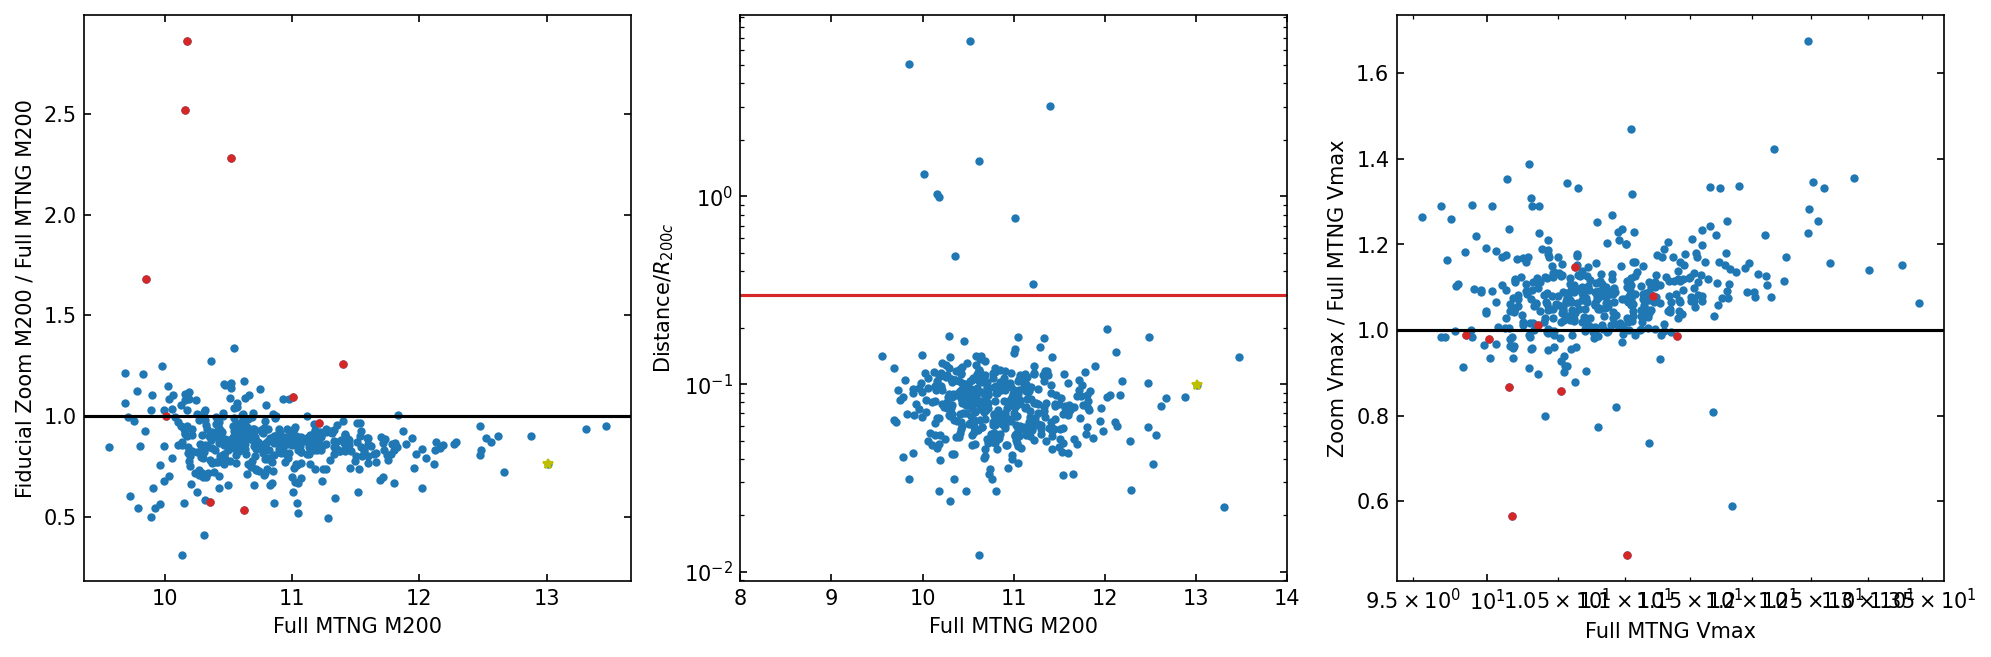

In [59]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(16,5))

w = np.where(dmatch>0.3)

Xarr = np.log10(1e10*mtng.fof['halo_m200b'][sel_z])
Yarr = (zoom.fof['halo_m200b'][psel][xmatch] / mtng.fof['halo_m200b'][sel_z])

Xarr_out = np.log10(1e10*mtng.fof['halo_m200b'][sel_z][w])
Yarr_out = (zoom.fof['halo_m200b'][psel][xmatch][w] / mtng.fof['halo_m200b'][sel_z][w])

ax[0].plot(Xarr, Yarr, marker='o', color='C0', ms=3, ls='')
ax[0].plot(Xarr_out, Yarr_out, marker='o', color='C3', ms=3, ls='')

ax[0].plot(Xarr[ihalo], Yarr[ihalo], marker='*', color='y', ms=5, ls='')

ax[0].axhline(1, color='k')

ax[0].set_xlabel('Full MTNG M200')
ax[0].set_ylabel('Fiducial Zoom M200 / Full MTNG M200')

#

ax[1].set_xlabel('Full MTNG M200')
ax[1].set_ylabel('Distance$/R_{200c}$')

ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z]), dmatch, marker='o', color='C0', ms=3, ls='')
ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z][ihalo]), dmatch[ihalo], marker='*', color='y', ms=5, ls='')

ax[1].set_xlim(8,14)
ax[1].axhline(0.3, color='C3')

ax[1].set_yscale('log')

#

ax[2].set_xscale('log')

ax[2].set_xlabel('Full MTNG Vmax')
ax[2].set_ylabel('Zoom Vmax / Full MTNG Vmax')

ax[2].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z]), mtng.sub['vmax'][mtng.fof['halo_firstsub'][sel_z]] / zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel][xmatch]], marker='o', color='C0', ms=3, ls='')
ax[2].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z][w]), mtng.sub['vmax'][mtng.fof['halo_firstsub'][sel_z][w]] / zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel][xmatch][w]], marker='o', color='C3', ms=3, ls='')

ax[2].axhline(1, color='k')

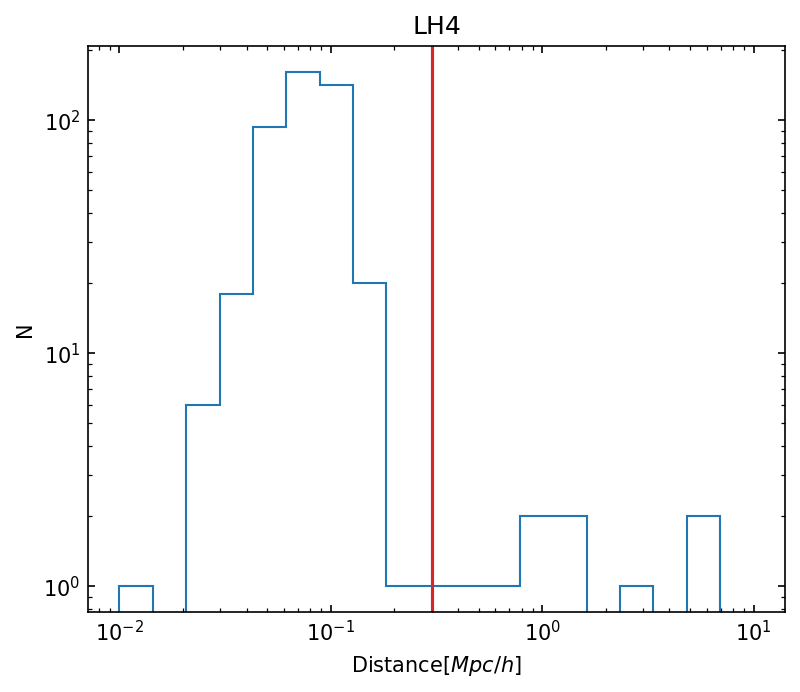

In [60]:
fig, ax = plt.subplots(dpi=150, figsize=(6,5))

ax.set_xscale('log')
ax.hist(dmatch, bins=np.logspace(-2,1,20), log=True, histtype='step')

ax.set_xlabel('Distance$[Mpc/h]$')
ax.set_ylabel('N')

plt.title('LH4')

ax.axvline(0.3, color='C3')

### Let's work in a specific region

We will focus on one of the zoom halos

In [61]:
Pzoom = zoom.fof['halo_pos'][psel[xmatch]]
Pmtng = mtng.fof['halo_pos'][sel_z]

In [62]:
center = Pmtng[ihalo]

In [63]:
L_p = 5
z_slab = 5
xmin = np.array([center[0]-L_p/2,center[1]-L_p/2,center[2]-z_slab/2])

mtng_sel = np.where( (mtng.fof['halo_pos'][:,0]>(center[0]-L_p/2)) & (mtng.fof['halo_pos'][:,0]<(center[0]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,1]>(center[1]-L_p/2)) & (mtng.fof['halo_pos'][:,1]<(center[1]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,2]>(center[2]-z_slab/2)) & (mtng.fof['halo_pos'][:,2]<(center[2]+z_slab/2)) &\
                     (mtng.fof['halo_m200b']>0))[0]

In [64]:
zoom_grid = {}

part = ['dm', 'gas', 'stars']

for type in range(len(part)):
    zoom_sel = np.where( (getattr(zoom_snap,part[type])['pos'][:,0]>(center[0]-L_p/2)) & (getattr(zoom_snap,part[type])['pos'][:,0]<(center[0]+L_p/2)) &\
                        (getattr(zoom_snap,part[type])['pos'][:,1]>(center[1]-L_p/2)) & (getattr(zoom_snap,part[type])['pos'][:,1]<(center[1]+L_p/2)) &\
                        (getattr(zoom_snap,part[type])['pos'][:,2]>(center[2]-z_slab/2)) & (getattr(zoom_snap,part[type])['pos'][:,2]<(center[2]+z_slab/2)) )[0]

    zoom_grid[part[type]] = bacco.statistics.compute_mesh(pos=getattr(zoom_snap, part[type])['pos'][zoom_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

In [65]:
sel_pos = (mtng.fof['halo_pos'][mtng_sel]-xmin[np.newaxis, :])/L_p * 512

/tmp/ipykernel_367543/1785820329.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[type, i].set_xticklabels(['{:.0f}'.format(xticklabels[i]) for i in range(len(xticklabels))])
/tmp/ipykernel_367543/1785820329.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[type, i].set_yticklabels(['{:.0f}'.format(yticklabels[i]) for i in range(len(yticklabels))])


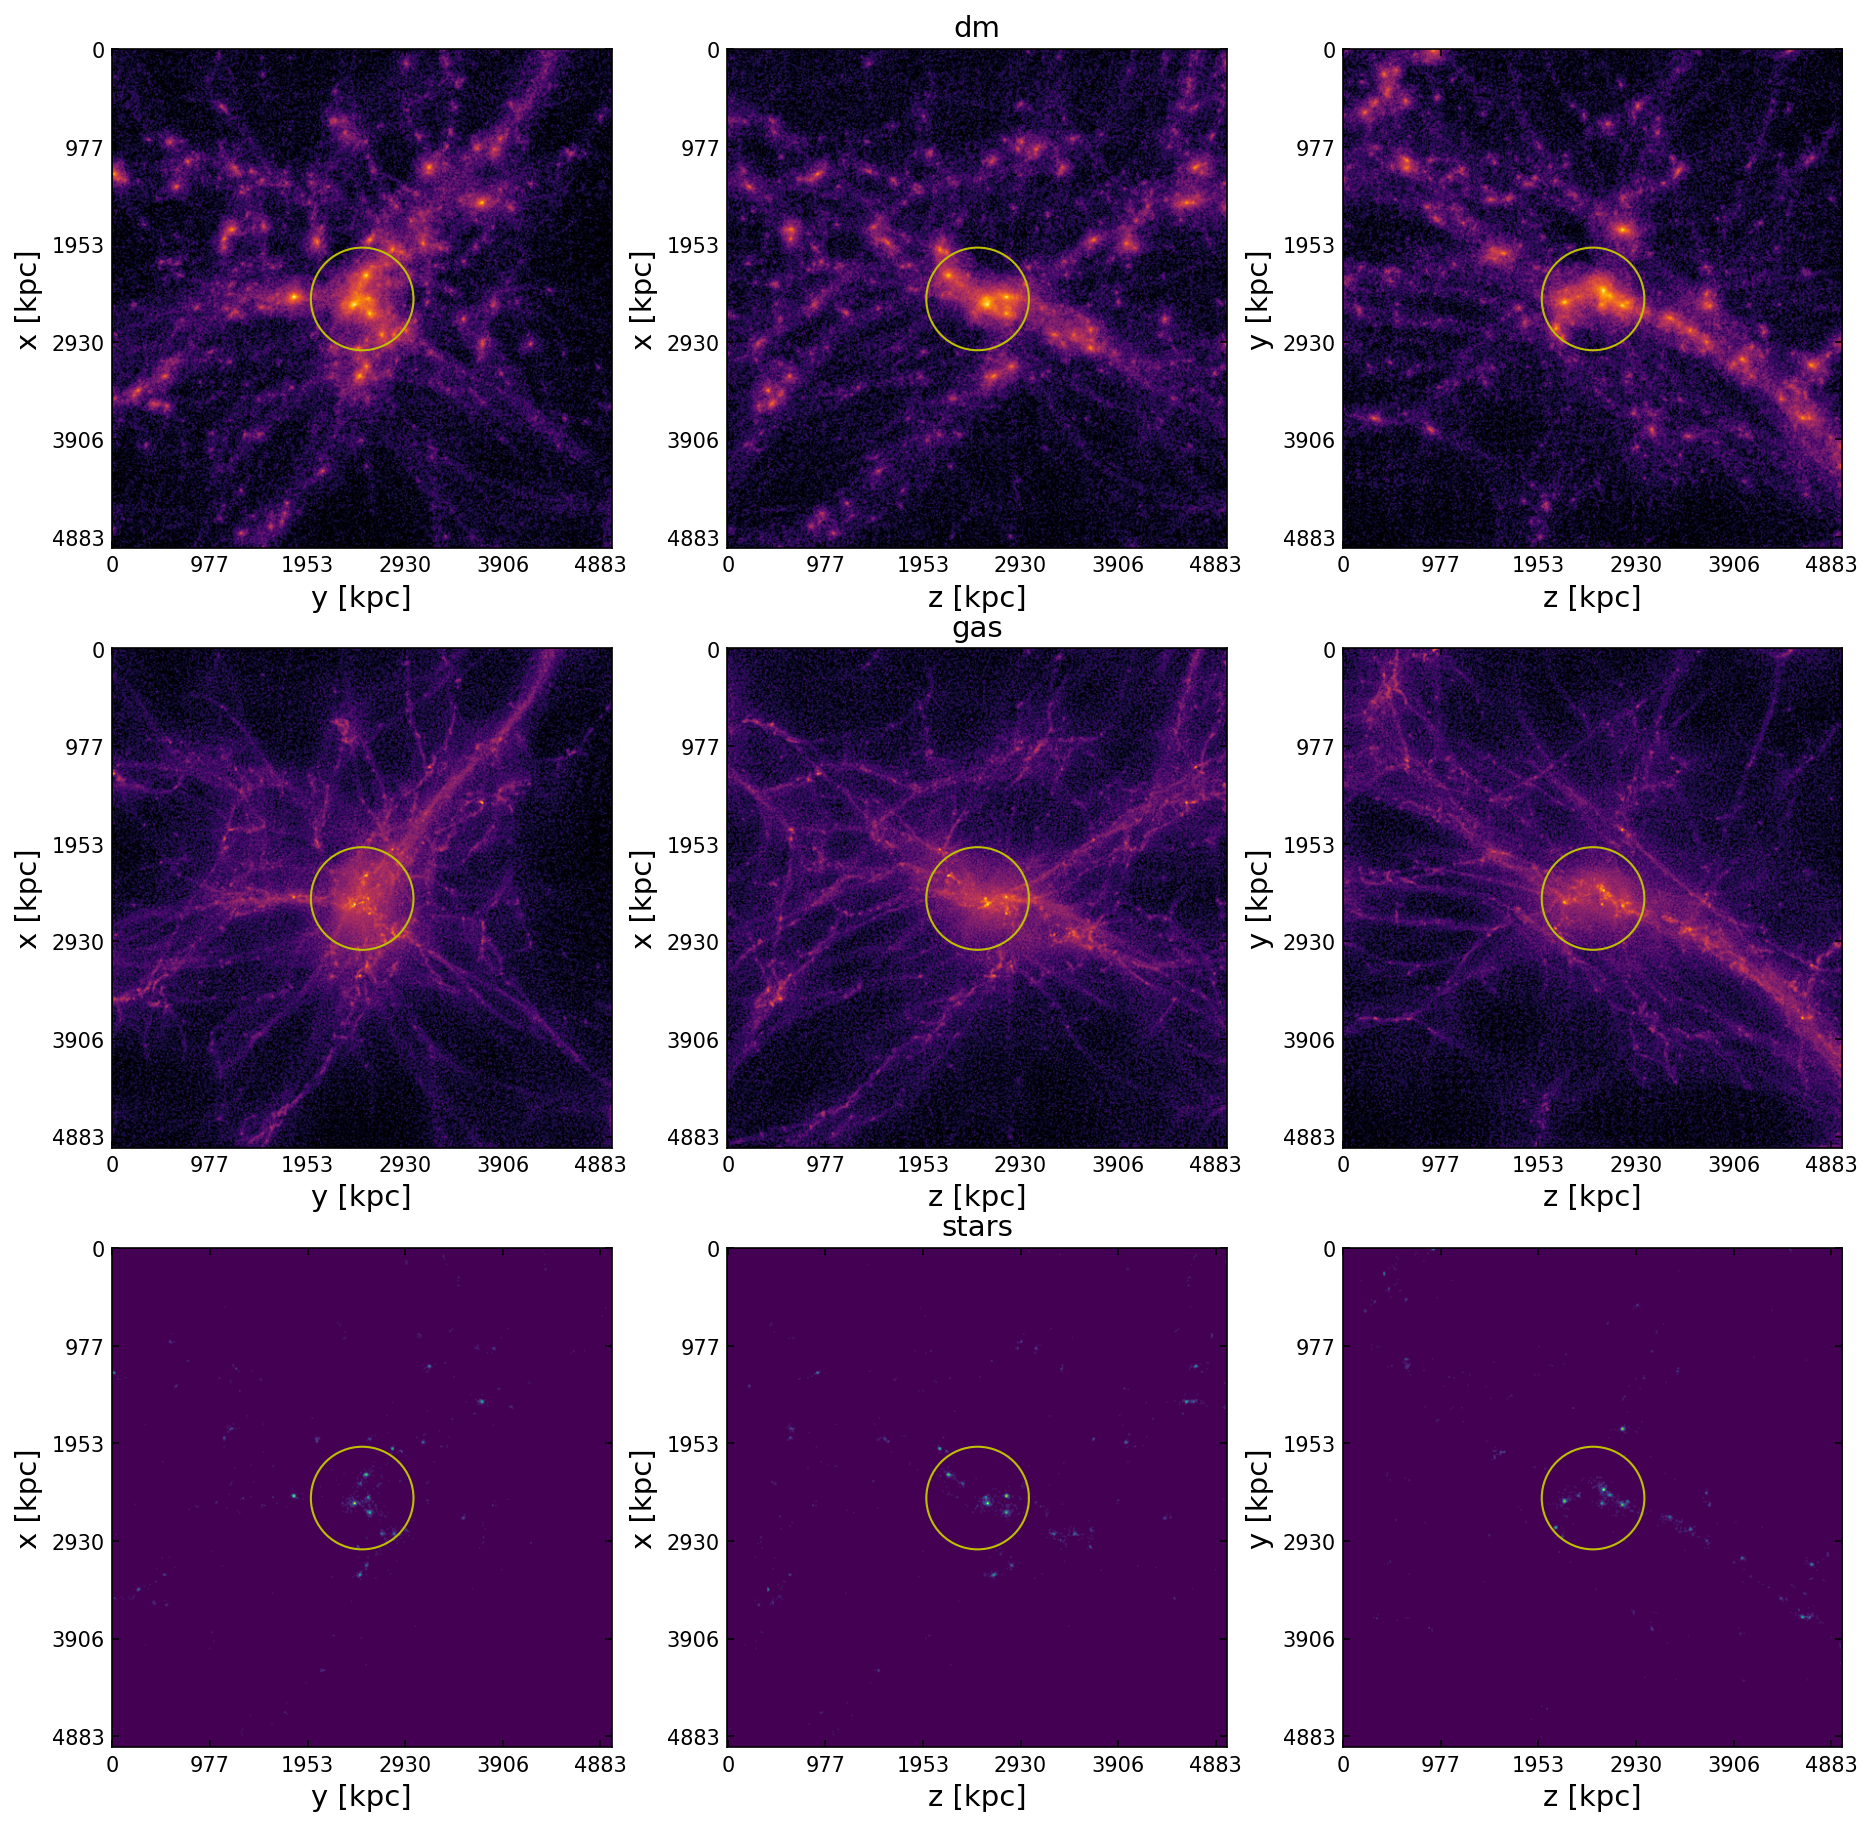

In [66]:
Pmtng_norm = (Pmtng-xmin[np.newaxis, :])/L_p * 512
Pzoom_norm = (Pzoom-xmin[np.newaxis, :])/L_p * 512

fig, ax = plt.subplots(3, 3, dpi=150, figsize=(15,15))

cmap = ['inferno', 'inferno', 'viridis']

for type in range(len(part)):
    ax[type, 0].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=2)), cmap=cmap[type])
    ax[type, 1].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=1)), cmap=cmap[type])
    ax[type, 2].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=0)), cmap=cmap[type])

    for i in range(3):
        xticklabels = 1000 * ax[type, i].get_xticks() / 512 * L_p
        yticklabels = 1000 * ax[type, i].get_yticks() / 512 * L_p
        ax[type, i].set_xticklabels(['{:.0f}'.format(xticklabels[i]) for i in range(len(xticklabels))])
        ax[type, i].set_yticklabels(['{:.0f}'.format(yticklabels[i]) for i in range(len(yticklabels))])

    ax[type, 0].set_xlabel('y [kpc]', fontsize=14)
    ax[type, 0].set_ylabel('x [kpc]', fontsize=14)

    ax[type, 1].set_xlabel('z [kpc]', fontsize=14)
    ax[type, 1].set_ylabel('x [kpc]', fontsize=14)

    ax[type, 2].set_xlabel('z [kpc]', fontsize=14)
    ax[type, 2].set_ylabel('y [kpc]', fontsize=14)

    ax[type, 1].set_title(part[type], fontsize=14)

    # for i in range(sel_pos.shape[0]):
    #     circle = plt.Circle((sel_pos[i,1],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    #     ax[0].add_artist(circle)
    #     circle = plt.Circle((sel_pos[i,2],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    #     ax[1].add_artist(circle)
    #     circle = plt.Circle((sel_pos[i,2],sel_pos[i,1]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    #     ax[2].add_artist(circle)

    # ax[0].plot( Pzoom_norm[ihalo][1], Pzoom_norm[ihalo][0], 'y*', ms=3)
    # ax[1].plot( Pzoom_norm[ihalo][2], Pzoom_norm[ihalo][0], 'y*', ms=3)
    # ax[2].plot( Pzoom_norm[ihalo][2], Pzoom_norm[ihalo][1], 'y*', ms=3)

    circle = plt.Circle((Pmtng_norm[ihalo][1], Pmtng_norm[ihalo][0]), mtng.fof['halo_r200c'][sel_z][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 0].add_artist(circle)
    circle = plt.Circle((Pmtng_norm[ihalo][2], Pmtng_norm[ihalo][0]), mtng.fof['halo_r200c'][sel_z][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 1].add_artist(circle)
    circle = plt.Circle((Pmtng_norm[ihalo][2], Pmtng_norm[ihalo][1]), mtng.fof['halo_r200c'][sel_z][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 2].add_artist(circle)

plt.savefig('../images/zoom{:d}_LH4.pdf'.format(ihalo), bbox_inches='tight')

### Save the cross-match

In [67]:
np.save("/lscratch/fgmaion/MTNG-resims/cross-match/xmatch_LH4.npy", [{'xmatch':psel[xmatch], 'dmatch':dmatch}])